In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("/Users/ilyaklimasin/Downloads/archive-4/application_train.csv")

print(df.shape)

(307511, 122)


In [2]:
x = df.drop(columns=["TARGET", "SK_ID_CURR"])
y = df["TARGET"]
application_ids = df["SK_ID_CURR"]
print(x.shape)
print(y.shape)

(307511, 120)
(307511,)


In [5]:
from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, stratify=y, random_state=42)
x_valid, x_test, y_valid, y_test = train_test_split(x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
print("Train: ", x_train.shape)
print("Validation: ", x_valid.shape)
print("Test: ", x_test.shape)
print("Train TARGET:", y_train.mean())
print("Validation TARGET:", y_valid.mean())
print("Test TARGET:", y_test.mean())

Train:  (184506, 120)
Validation:  (61502, 120)
Test:  (61503, 120)
Train TARGET: 0.08072908198107379
Validation TARGET: 0.08072908198107379
Test TARGET: 0.08072776937710356


In [8]:
def replace_employment_anomaly(data):
    result = data.copy()
    result["DAYS_EMPLOYED"] = result["DAYS_EMPLOYED"].replace(365243, np.nan)
    return result

X_train = replace_employment_anomaly(
    x_train
)

X_valid = replace_employment_anomaly(
    x_valid
)

X_test = replace_employment_anomaly(
    x_test
)
assert (
    X_train["DAYS_EMPLOYED"] == 365243
).sum() == 0

In [10]:
categorical_columns = x_train.select_dtypes(include="object").columns.tolist()
numeric_columns = x_train.select_dtypes(include=np.number).columns.tolist()

print("Categorical: ", len(categorical_columns))
print("Numeric: ", len(numeric_columns))

Categorical:  16
Numeric:  104


In [11]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    (
        "imputer", SimpleImputer(strategy="median"),
    ),
    (
        "scaler", StandardScaler(),
    )
])

In [12]:
from sklearn.preprocessing import OneHotEncoder
categorical_pipeline = Pipeline([
    (
        "imputer", SimpleImputer(strategy="most_frequent"),
    ),
    (
        "encoder", OneHotEncoder(handle_unknown="ignore"),
    ),
])

In [13]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_columns,
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_columns,
    ),
])

In [16]:
from sklearn.dummy import DummyClassifier
dummy_model = Pipeline([
    (
        "preprocessing", preprocessor,
    ),
    (
        "model", DummyClassifier(strategy="prior"),
    ),
])
dummy_model.fit(x_train,y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'AMT_CREDIT', 'AMT_ANNUITY',
                                                   'AMT_GOODS_PRICE',
                                                   'REGION_POPULATION_RELATIVE',
                                                   'DAYS_BIRTH',
                                                   'DAYS_EMPLOYED',
                                                   'DAYS_REGISTRATION',
                                                   'DAYS_ID_PUBLISH',
                                                   'OWN_CA...
                                                  ['NAME_CONTRACT_TYPE',
                                                   'CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_TYPE_SUITE',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE',
                                                   'WEEKDAY_APPR_PROCESS_START',
                                                   'ORGANIZATION_TYPE',
                                                   'FONDKAPREMONT_MODE',
                                                   'HOUSETYPE_MODE',
                                                   'WALLSMATERIAL_MODE',
                                                   'EMERGENCYSTATE_MODE'])])),
                ('model', DummyClassifier())])

In [17]:
dummy_probabilities = (
    dummy_model.predict_proba(
        X_valid
    )[:, 1]
)

In [18]:
from sklearn.linear_model import LogisticRegression 
logistic_model = Pipeline([
    (
        "preprocessing", preprocessor,
    ),
    (
        "model", LogisticRegression(max_iter=1000, random_state=42,),
    ),
])
logistic_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'AMT_CREDIT', 'AMT_ANNUITY',
                                                   'AMT_GOODS_PRICE',
                                                   'REGION_POPULATION_RELATIVE',
                                                   'DAYS_BIRTH',
                                                   'DAYS_EMPLOYED',
                                                   'DAYS_REGISTRATION',
                                                   'DAYS_ID_PUBLISH',
                                                   'OWN_CA...
                                                   'CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_TYPE_SUITE',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE',
                                                   'WEEKDAY_APPR_PROCESS_START',
                                                   'ORGANIZATION_TYPE',
                                                   'FONDKAPREMONT_MODE',
                                                   'HOUSETYPE_MODE',
                                                   'WALLSMATERIAL_MODE',
                                                   'EMERGENCYSTATE_MODE'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [19]:
logistic_probabilities = (
    logistic_model.predict_proba(
        X_valid
    )[:, 1]
)

In [21]:
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

def calculate_metrics(y_true, probabilities):
    return {
        "roc_auc":roc_auc_score(y_true, probabilities,),
        "pr_auc":average_precision_score(y_true, probabilities,),
        "brier_score": brier_score_loss(y_true, probabilities,),
    }

results = pd.DataFrame([
    {
        "model": "Dummy",
        **calculate_metrics(
            y_valid,
            dummy_probabilities,
        ),
    },
    {
        "model": "Logistic Regression",
        **calculate_metrics(
            y_valid,
            logistic_probabilities,
        ),
    },
])

results


,model,roc_auc,pr_auc,brier_score
0,Dummy,0.500000,0.080729,0.074212
1,Logistic Regression,0.712688,0.213846,0.069570


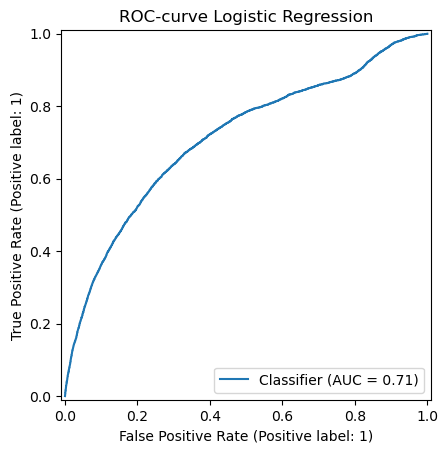

In [24]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_valid, logistic_probabilities,)
plt.title("ROC-curve Logistic Regression")
plt.show()

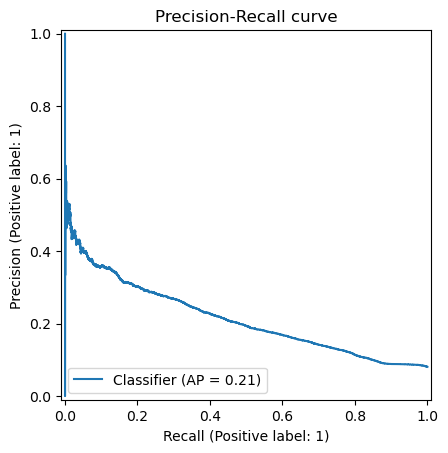

In [25]:
from sklearn.metrics import (
    PrecisionRecallDisplay,
)

PrecisionRecallDisplay.from_predictions(
    y_valid,
    logistic_probabilities,
)

plt.title(
    "Precision-Recall curve"
)
plt.show()

## Выводы второго этапа

- Исходные данные разделены на тренировочную, валидационную и тестовую выборки со стратификацией по `TARGET`. Доля положительного класса во всех выборках осталась сопоставимой.
- Идентификатор `SK_ID_CURR` исключён из признаков модели.
- Заполнение пропусков, масштабирование числовых признаков и кодирование категорий выполнялись внутри `Pipeline`. Все параметры preprocessing были рассчитаны только на тренировочной выборке, что позволило избежать утечки данных.
- В качестве наивного baseline использован `DummyClassifier`, предсказывающий априорную вероятность положительного класса.
- Logistic Regression превзошла Dummy baseline по ROC-AUC, PR-AUC и Brier score.
- ROC-AUC увеличилась с `0.5000` до `0.7130`. Это означает, что Logistic Regression заметно лучше случайного baseline ранжирует клиентов по уровню кредитного риска.
- PR-AUC увеличилась с `0.0807` до `0.2139`, то есть примерно в 2,65 раза относительно базового уровня. Эта метрика особенно важна из-за редкости класса `TARGET = 1`.
- Brier score снизился с `0.0742` до `0.0696`. Следовательно, вероятностные прогнозы Logistic Regression оказались качественнее прогнозов Dummy baseline.
- Полученные результаты показывают, что даже интерпретируемая линейная модель извлекает полезный сигнал из признаков текущей кредитной заявки.
- Валидационная выборка использовалась для сравнения моделей. Тестовая выборка не использовалась и сохранена для однократной финальной оценки выбранного решения.